In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import models, datasets, transforms
from torch.utils.data import Dataset, DataLoader  
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np 
import cv2
from PIL import Image
import os

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda


In [50]:
import os
import pandas as pd
from torch.utils.data import Dataset, DataLoader, random_split
from torchvision import transforms, datasets
from PIL import Image

# Transformări pentru imagini
transform_train = transforms.Compose([
    transforms.Resize((299, 299)),  
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.RandomAffine(degrees=0, translate=(0.1, 0.1)), 
    transforms.ColorJitter(brightness=0.2, contrast=0.2),  
    transforms.ToTensor(),
])

transform_val_test = transforms.Compose([
    transforms.Resize((299, 299)),
    transforms.ToTensor(),
])

class CustomDataset(Dataset):
    def __init__(self, csv_file, transform=None):
        self.csv_file = csv_file
        self.data = pd.read_csv(csv_file)
        self.transform = transform

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        if "Meta.csv" in self.csv_file:  
            img_path = self.data.iloc[idx, 0]  
            label = self.data.iloc[idx, 1]    
        elif "Test.csv" in self.csv_file:  
            img_path = self.data.iloc[idx, -1]  
            label = self.data.iloc[idx, -2]    
        else:
            raise ValueError(f"Unknown CSV file structure: {self.csv_file}")

        image = Image.open(img_path).convert("RGB")  

        if self.transform:
            image = self.transform(image)

        return image, label

full_train_dataset = datasets.ImageFolder("Train", transform=transform_train)

# Împartim dataset-ul în 80% pentru train și 20% pentru validare
train_size = int(0.8 * len(full_train_dataset))
val_size = len(full_train_dataset) - train_size
train_dataset, val_dataset = random_split(full_train_dataset, [train_size, val_size])

test_dataset = CustomDataset(csv_file="Test.csv", transform=transform_val_test)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

print(f"Train set: {len(train_dataset)} images")
print(f"Validation set: {len(val_dataset)} images")
print(f"Test set: {len(test_dataset)} images")

dataloaders = {
    "train": train_loader,
    "val": val_loader,
    "test": test_loader
}

Train set: 31367 images
Validation set: 7842 images
Test set: 12630 images


In [58]:
import torch
import torch.nn as nn
from torchvision.models import (
    resnet18, ResNet18_Weights,
    vgg16, VGG16_Weights,
    mobilenet_v3_large, MobileNet_V3_Large_Weights,
    alexnet, AlexNet_Weights,
    efficientnet_b0, EfficientNet_B0_Weights,
    vgg19, VGG19_Weights
)

def replace_last_layer(model, last_layer_attr, num_classes):
    
    last_layer = eval(f"model.{last_layer_attr}")
    
    if not hasattr(last_layer, "in_features"):
        raise ValueError(f"Atributul {last_layer_attr} nu are `in_features`. Verifică arhitectura!")
    
    in_features = last_layer.in_features
    new_layer = nn.Linear(in_features, num_classes)
    exec(f"model.{last_layer_attr} = new_layer")
    
    return model


def create_model(model_name, num_classes, method):
    model_map = {
        "resnet18": (resnet18, ResNet18_Weights.IMAGENET1K_V1, "fc"),
        "vgg16": (vgg16, VGG16_Weights.IMAGENET1K_V1, "classifier[6]"),
        "vgg19": (vgg19, VGG19_Weights.IMAGENET1K_V1, "classifier[6]"),
        "mobilenet_v3": (mobilenet_v3_large, MobileNet_V3_Large_Weights.IMAGENET1K_V1, "classifier[3]"),
        "alexnet": (alexnet, AlexNet_Weights.IMAGENET1K_V1, "classifier[6]"),
        "efficientnet_b0": (efficientnet_b0, EfficientNet_B0_Weights.IMAGENET1K_V1, "classifier[1]")
    }

    if model_name not in model_map:
        raise ValueError(f"Modelul {model_name} nu este implementat!")

    model_fn, weights_enum, last_layer_attr = model_map[model_name]

    if method not in ["from_scratch", "feature_extraction", "fine_tuning"]:
        raise ValueError(f"Metoda {method} nu este validă! Alege: from_scratch, feature_extraction sau fine_tuning.")
    
    weights = None if method == "from_scratch" else weights_enum

    model = model_fn(weights=weights)

    # Feature extraction: Înghețăm parametrii
    if method == "feature_extraction":
        for param in model.parameters():
            param.requires_grad = False
        for param in model.classifier.parameters():
            param.requires_grad = True

    try:
        last_layer_params = eval(f"model.{last_layer_attr}.parameters()")
        for param in last_layer_params:
            param.requires_grad = True
    except AttributeError:
        raise ValueError(f"Modelul {model_name} nu are atributul {last_layer_attr}.")

    model = replace_last_layer(model, last_layer_attr, num_classes)

    return model.to(device)

In [59]:
import torch
import torch.optim as optim
import copy
import time

def train_model(model, dataloaders, criterion, method, num_epochs=10, learning_rate=0.001, patience=3):
    if method == "feature_extraction":
        optimizer = optim.Adam(filter(lambda p: p.requires_grad, model.parameters()), lr=learning_rate)
    else:  # from_scratch sau fine_tuning
        optimizer = optim.Adam(model.parameters(), lr=learning_rate)

    best_model_wts = copy.deepcopy(model.state_dict())
    best_val_loss = float("inf")
    history = {"train_loss": [], "val_loss": [], "train_acc": [], "val_acc": []}

    no_improve_epochs = 0

    start_time = time.time()

    for epoch in range(num_epochs):
        print(f"Epoch {epoch + 1}/{num_epochs}")
        print("-" * 20)

        for phase in ["train", "val"]:
            if phase == "train":
                model.train()  # Setăm modelul în mod antrenare
            else:
                model.eval()  # Setăm modelul în mod evaluare

            running_loss = 0.0
            running_corrects = 0

            for inputs, labels in dataloaders[phase]:
                inputs, labels = inputs.to(device), labels.to(device)

                optimizer.zero_grad()

                # Calculăm predicțiile și pierderea
                with torch.set_grad_enabled(phase == "train"):
                    outputs = model(inputs)
                    _, preds = torch.max(outputs, 1)
                    loss = criterion(outputs, labels)

                    # Backpropagation și optimizare doar în modul train
                    if phase == "train":
                        loss.backward()
                        optimizer.step()

                # Adunăm pierderea și predicțiile corecte
                running_loss += loss.item() * inputs.size(0)
                running_corrects += torch.sum(preds == labels.data)

            # Calculăm pierderea și acuratețea pe epocă
            epoch_loss = running_loss / len(dataloaders[phase].dataset)
            epoch_acc = running_corrects.double() / len(dataloaders[phase].dataset)

            history[f"{phase}_loss"].append(epoch_loss)
            history[f"{phase}_acc"].append(epoch_acc.item())

            print(f"{phase.capitalize()} Loss: {epoch_loss:.4f} Acc: {epoch_acc:.4f}")

            # Salvăm cel mai bun model pe baza pierderii de validare
            if phase == "val":
                if epoch_loss < best_val_loss:
                    best_val_loss = epoch_loss
                    best_model_wts = copy.deepcopy(model.state_dict())
                    no_improve_epochs = 0  # Resetăm numărătoarea pentru early stopping
                else:
                    no_improve_epochs += 1

        if no_improve_epochs >= patience:
            print("Early stopping triggered!")
            break

    total_time = time.time() - start_time
    print(f"Training complete in {total_time // 60:.0f}m {total_time % 60:.0f}s")
    print(f"Best validation loss: {best_val_loss:.4f}")

    # Încărcăm cele mai bune greutăți
    model.load_state_dict(best_model_wts)
    return model, copy.deepcopy(history)

In [53]:
from torchvision import datasets
from collections import Counter
from torch.utils.data import DataLoader, random_split

full_train_dataset = datasets.ImageFolder("Train", transform=transform)

train_size = int(0.8 * len(full_train_dataset))
val_size = len(full_train_dataset) - train_size
train_dataset, val_dataset = random_split(full_train_dataset, [train_size, val_size])

test_dataset = CustomDataset(csv_file="Test.csv", transform=transform)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

print(f"Train set: {len(train_dataset)} images")
print(f"Validation set: {len(val_dataset)} images")
print(f"Test set: {len(test_dataset)} images")

dataloaders = {
    "train": train_loader,
    "val": val_loader,
    "test": test_loader
}

train_indices = train_dataset.indices
val_indices = val_dataset.indices

train_files = set([os.path.abspath(full_train_dataset.samples[i][0]) for i in train_indices])
val_files = set([os.path.abspath(full_train_dataset.samples[i][0]) for i in val_indices])
test_files = set(test_dataset.data["Path"].apply(os.path.abspath))  # Extrage calea absolută din DataFrame

# Verifică suprapunerile
overlap_train_val = train_files.intersection(val_files)
overlap_train_test = train_files.intersection(test_files)
overlap_val_test = val_files.intersection(test_files)

print("=== Verificare suprapuneri între seturi ===")
print(f"Imagini comune între train și val: {len(overlap_train_val)}")
print(f"Imagini comune între train și test: {len(overlap_train_test)}")
print(f"Imagini comune între val și test: {len(overlap_val_test)}")

# Verifică distribuția claselor
train_classes = [full_train_dataset.samples[i][1] for i in train_indices]
val_classes = [full_train_dataset.samples[i][1] for i in val_indices]
test_classes = test_dataset.data["ClassId"].tolist()

print("\n=== Distribuția claselor în seturi ===")
print(f"Train class distribution: {dict(Counter(train_classes))}")
print(f"Val class distribution: {dict(Counter(val_classes))}")
print(f"Test class distribution: {dict(Counter(test_classes))}")

Train set: 31367 images
Validation set: 7842 images
Test set: 12630 images
=== Verificare suprapuneri între seturi ===
Imagini comune între train și val: 0
Imagini comune între train și test: 0
Imagini comune între val și test: 0

=== Distribuția claselor în seturi ===
Train class distribution: {5: 1732, 32: 1673, 40: 1154, 10: 968, 41: 1129, 23: 1137, 13: 274, 18: 1202, 2: 1610, 7: 499, 38: 1518, 12: 1822, 8: 329, 27: 548, 39: 331, 1: 1784, 29: 954, 21: 426, 42: 1186, 3: 1050, 9: 884, 0: 172, 34: 1603, 4: 1705, 16: 385, 6: 623, 14: 262, 15: 293, 19: 489, 37: 189, 36: 191, 25: 607, 33: 231, 28: 340, 22: 212, 30: 315, 20: 185, 17: 217, 11: 156, 24: 362, 31: 156, 26: 183, 35: 281}
Val class distribution: {41: 281, 1: 436, 10: 232, 6: 157, 18: 298, 32: 397, 42: 284, 39: 89, 25: 173, 40: 286, 2: 400, 16: 125, 23: 273, 12: 428, 5: 428, 4: 395, 34: 377, 20: 55, 15: 97, 21: 114, 8: 91, 0: 38, 3: 270, 22: 58, 19: 111, 29: 246, 27: 141, 36: 49, 7: 131, 38: 342, 30: 75, 26: 57, 28: 80, 37: 51, 3

In [19]:
import os
import pandas as pd
import torch
import torch.nn as nn
from torchvision.models import resnet18
import json

meta_data = pd.read_csv("Meta.csv")
num_classes = meta_data["ClassId"].nunique()  # Sau num_classes = 43 dacă știi deja

criterion = nn.CrossEntropyLoss()

method_params = {
    "from_scratch": {"num_epochs": 10, "learning_rate": 0.001},
    "feature_extraction": {"num_epochs": 10, "learning_rate": 0.001},
    "fine_tuning": {"num_epochs": 15, "learning_rate": 0.001}
}

os.makedirs("results", exist_ok=True)

resnet_results = []

for method, params in method_params.items():
    print(f"\nTraining ResNet18 with method: {method}")
    print("-" * 40)

    model = create_model("resnet18", num_classes=num_classes, method=method)

    model, history = train_model(
        model=model,
        dataloaders=dataloaders,
        criterion=criterion,
        method=method,
        num_epochs=params["num_epochs"],
        learning_rate=params["learning_rate"],
        patience=5  # Early stopping pentru feature_extraction și fine_tuning
    )

    # Salvăm modelul antrenat si istoricul
    model_path = f"results/resnet18_{method}_model.pth"
    torch.save(model.state_dict(), model_path)
    print(f"Model saved at {model_path}")

    history_path = f"results/resnet18_{method}_history.json"
    with open(history_path, "w") as f:
        json.dump(history, f)
    print(f"Training history saved at {history_path}")

    resnet_results.append({"method": method, "history": history, "model_path": model_path, "history_path": history_path})

    # Afișez ultimele valori pentru pierdere și acuratețe
    print(f"\nFinal results for {method}:")
    print(f"Train Loss: {history['train_loss'][-1]:.4f}")
    print(f"Val Loss: {history['val_loss'][-1]:.4f}")
    print(f"Train Acc: {history['train_acc'][-1]:.4f}")
    print(f"Val Acc: {history['val_acc'][-1]:.4f}")

print("\nSummary of results:")
for result in resnet_results:
    method = result["method"]
    best_val_acc = max(result["history"]["val_acc"])
    print(f"Method: {method}, Best Val Acc: {best_val_acc:.4f}")


Training ResNet18 with method: from_scratch
----------------------------------------
Epoch 1/10
--------------------
Train Loss: 2.0578 Acc: 0.3839
Val Loss: 0.8870 Acc: 0.7539
Epoch 2/10
--------------------
Train Loss: 0.2259 Acc: 0.9354
Val Loss: 0.0382 Acc: 0.9921
Epoch 3/10
--------------------
Train Loss: 0.0473 Acc: 0.9873
Val Loss: 0.0381 Acc: 0.9889
Epoch 4/10
--------------------
Train Loss: 0.0261 Acc: 0.9933
Val Loss: 0.0502 Acc: 0.9852
Epoch 5/10
--------------------
Train Loss: 0.0202 Acc: 0.9947
Val Loss: 0.0066 Acc: 0.9985
Epoch 6/10
--------------------
Train Loss: 0.0217 Acc: 0.9936
Val Loss: 0.0334 Acc: 0.9902
Epoch 7/10
--------------------
Train Loss: 0.0224 Acc: 0.9936
Val Loss: 0.0107 Acc: 0.9968
Epoch 8/10
--------------------
Train Loss: 0.0126 Acc: 0.9961
Val Loss: 0.0697 Acc: 0.9828
Epoch 9/10
--------------------
Train Loss: 0.0137 Acc: 0.9963
Val Loss: 0.0076 Acc: 0.9978
Epoch 10/10
--------------------
Train Loss: 0.0124 Acc: 0.9963
Val Loss: 0.0211 Acc: 

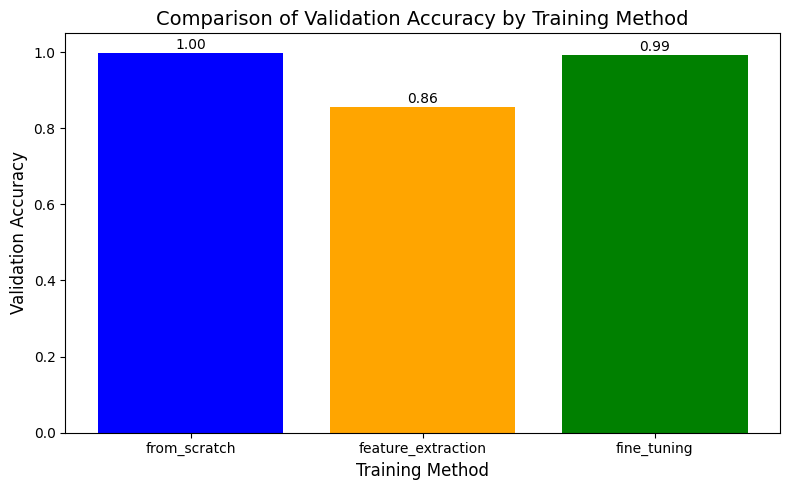

In [22]:
import matplotlib.pyplot as plt
import numpy as np

methods = ['from_scratch', 'feature_extraction', 'fine_tuning']
accuracy = [0.99847, 0.857387, 0.993852]

# Creează graficul
plt.figure(figsize=(8, 5))  # Dimensiunea graficului
bars = plt.bar(methods, accuracy, color=['blue', 'orange', 'green'])

for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 0.01, f'{yval:.2f}', ha='center', fontsize=10)

plt.ylim(0, 1.05)
plt.title("Comparison of Validation Accuracy by Training Method", fontsize=14)
plt.ylabel("Validation Accuracy", fontsize=12)
plt.xlabel("Training Method", fontsize=12)
plt.tight_layout()
plt.show()

In [ ]:
import torch
from torchvision import datasets, transforms
import os
import json

os.makedirs("results", exist_ok=True)
criterion = nn.CrossEntropyLoss()

models_to_train = ["mobilenet_v3", "alexnet"] #"vgg16", "vgg19"]
num_epochs = 10  
results = []

# Antrenarea fiecărui model
for model_name in models_to_train:
    print(f"\n=== Training model: {model_name} ===")
    try:
        model = create_model(model_name, num_classes=len(full_train_dataset.classes), method="feature_extraction")
        print(f"Model {model_name} created successfully!")

        model, history = train_model(
            model=model,
            dataloaders=dataloaders,
            criterion=criterion,
            method="feature_extraction",
            num_epochs=num_epochs,
            learning_rate=0.001  
        )
        print(f"Model {model_name} trained successfully!")

        model_weights_path = f"results/{model_name}_weights.pth"
        history_path = f"results/{model_name}_history.json"

        torch.save(model.state_dict(), model_weights_path)
        print(f"Model {model_name} weights saved at {model_weights_path}!")

        with open(history_path, "w") as f:
            json.dump(history, f)
        print(f"Training history saved at {history_path}!")

        results.append({
            "model_name": model_name,
            "model_weights_path": model_weights_path,
            "history_path": history_path,
            "best_val_acc": max(history["val_acc"])  # Cea mai bună acuratețe pe validare
        })

    except Exception as e:
        print(f"An error occurred while training {model_name}: {e}")

print("\n=== Summary of results ===")
for result in results:
    print(f"Model: {result['model_name']}, Best Val Acc: {result['best_val_acc']:.4f}")


=== Training model: mobilenet_v3 ===
Model mobilenet_v3 created successfully!
Epoch 1/10
--------------------
Train Loss: 0.9363 Acc: 0.7103
Val Loss: 0.4988 Acc: 0.8349
Epoch 2/10
--------------------
Train Loss: 0.4410 Acc: 0.8533
Val Loss: 0.2988 Acc: 0.9013
Epoch 3/10
--------------------
Train Loss: 0.3097 Acc: 0.8961
Val Loss: 0.2603 Acc: 0.9106
Epoch 4/10
--------------------
Train Loss: 0.2621 Acc: 0.9099
Val Loss: 0.1972 Acc: 0.9339
Epoch 5/10
--------------------
Train Loss: 0.2238 Acc: 0.9239
Val Loss: 0.1994 Acc: 0.9333
Epoch 6/10
--------------------
Train Loss: 0.1906 Acc: 0.9351
Val Loss: 0.1718 Acc: 0.9429
Epoch 7/10
--------------------
Train Loss: 0.1783 Acc: 0.9389
Val Loss: 0.2159 Acc: 0.9292
Epoch 8/10
--------------------
Train Loss: 0.1726 Acc: 0.9418
Val Loss: 0.1802 Acc: 0.9452
Epoch 9/10
--------------------
Train Loss: 0.1663 Acc: 0.9442
Val Loss: 0.1456 Acc: 0.9527
Epoch 10/10
--------------------
Train Loss: 0.1570 Acc: 0.9482
Val Loss: 0.1295 Acc: 0.9603


KeyboardInterrupt: 

In [62]:
import torch
from torchvision import datasets, transforms
import os
import json

os.makedirs("results", exist_ok=True)
criterion = nn.CrossEntropyLoss()

models_to_train = ["efficientnet_b0"] #"vgg16", "vgg19"]
num_epochs = 10  
results = []

for model_name in models_to_train:
    print(f"\n=== Training model: {model_name} ===")
    try:
        model = create_model(model_name, num_classes=len(full_train_dataset.classes), method="feature_extraction")
        print(f"Model {model_name} created successfully!")

        model, history = train_model(
            model=model,
            dataloaders=dataloaders,
            criterion=criterion,
            method="feature_extraction",
            num_epochs=num_epochs,
            learning_rate=0.001 
        )
        print(f"Model {model_name} trained successfully!")

        model_weights_path = f"results/{model_name}_weights.pth"
        history_path = f"results/{model_name}_history.json"

        torch.save(model.state_dict(), model_weights_path)
        print(f"Model {model_name} weights saved at {model_weights_path}!")

        with open(history_path, "w") as f:
            json.dump(history, f)
        print(f"Training history saved at {history_path}!")

        results.append({
            "model_name": model_name,
            "model_weights_path": model_weights_path,
            "history_path": history_path,
            "best_val_acc": max(history["val_acc"])  # Cea mai bună acuratețe pe validare
        })

    except Exception as e:
        print(f"An error occurred while training {model_name}: {e}")

print("\n=== Summary of results ===")
for result in results:
    print(f"Model: {result['model_name']}, Best Val Acc: {result['best_val_acc']:.4f}")


=== Training model: efficientnet_b0 ===
Model efficientnet_b0 created successfully!
Epoch 1/10
--------------------
Train Loss: 1.4722 Acc: 0.6248
Val Loss: 0.7776 Acc: 0.8114
Epoch 2/10
--------------------
Train Loss: 0.7992 Acc: 0.7819
Val Loss: 0.5835 Acc: 0.8579
Epoch 3/10
--------------------
Train Loss: 0.6472 Acc: 0.8176
Val Loss: 0.4555 Acc: 0.8834
Epoch 4/10
--------------------
Train Loss: 0.5690 Acc: 0.8335
Val Loss: 0.4458 Acc: 0.8952
Epoch 5/10
--------------------
Train Loss: 0.5204 Acc: 0.8433
Val Loss: 0.3654 Acc: 0.9008
Epoch 6/10
--------------------
Train Loss: 0.4937 Acc: 0.8523
Val Loss: 0.3239 Acc: 0.9104
Epoch 7/10
--------------------
Train Loss: 0.4666 Acc: 0.8584
Val Loss: 0.5152 Acc: 0.9111
Epoch 8/10
--------------------
Train Loss: 0.4438 Acc: 0.8605
Val Loss: 0.3239 Acc: 0.9176
Epoch 9/10
--------------------
Train Loss: 0.4301 Acc: 0.8641
Val Loss: 0.2926 Acc: 0.9213
Epoch 10/10
--------------------
Train Loss: 0.4232 Acc: 0.8664
Val Loss: 0.2681 Acc: 0

In [88]:
def load_model(model_name, num_classes, method="feature_extraction", weights_path=True):
    model = create_model(model_name, num_classes, method)
    if weights_path:
        model.load_state_dict(torch.load(weights_path))
        print(f"Model {model_name} loaded from {weights_path}")
    return model.to(device)

In [89]:
def evaluate_model(model, dataloader, criterion):
    model.eval()  # Setează modelul în modul de evaluare
    running_loss = 0.0
    running_corrects = 0
    criterion = nn.CrossEntropyLoss()

    with torch.no_grad():  # Dezactivează calculul gradientului pentru evaluare
        for inputs, labels in dataloader:
            inputs, labels = inputs.to(device), labels.to(device)

            # Obținem predicțiile
            outputs = model(inputs)
            _, preds = torch.max(outputs, 1)
            loss = criterion(outputs, labels)

            # Actualizează pierderea și numărul de predicții corecte
            running_loss += loss.item() * inputs.size(0)
            running_corrects += torch.sum(preds == labels.data)

    # Calculează pierderea și acuratețea medii
    total_loss = running_loss / len(dataloader.dataset)
    total_acc = running_corrects.double() / len(dataloader.dataset)

    return total_loss, total_acc.item()

In [ ]:
test_results = []
for model_name, weights_path in [
    ("alexnet", "results/alexnet_weights.pth"),
    ("mobilenet_v3", "results/mobilenet_v3_weights.pth"),
    ("efficientnet_b0", "results/efficientnet_b0_weights.pth")
]:
    try:
        criterion = nn.CrossEntropyLoss()
        model = create_model(model_name, num_classes=43, method="feature_extraction")
        model.load_state_dict(torch.load(weights_path))
        print(f"Model {model_name} loaded successfully from {weights_path}")

        test_loss, test_acc = evaluate_model(model, test_loader, criterion)
        print(f"Model: {model_name}, Test Loss: {test_loss:.4f}, Test Accuracy: {test_acc:.4f}")

        test_results.append({
            "Model": model_name,
            "Test Loss": test_loss,
            "Test Accuracy": test_acc
        })

    except Exception as e:
        print(f"An error occurred with {model_name}: {e}")

C:\Users\Asus\AppData\Local\Temp\ipykernel_8804\4205706780.py:13: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(weights_path))


Model alexnet loaded successfully from results/alexnet_weights.pth
Model: alexnet, Test Loss: 42.2087, Test Accuracy: 0.0582
Model mobilenet_v3 loaded successfully from results/mobilenet_v3_weights.pth
Model: mobilenet_v3, Test Loss: 22.2373, Test Accuracy: 0.0532
Model efficientnet_b0 loaded successfully from results/efficientnet_b0_weights.pth
Model: efficientnet_b0, Test Loss: 12.3602, Test Accuracy: 0.0449
